# Signal Investigation

It's finally time! The subsample is now quality controlled, mass-complete, binned into environment quartiles, binned by redshift and stellar mass, and binned into passive/active star formation!

Now, within each redshift and stellar mass bin, it's time to:

1. Measure passive fraction as a function of environment

2. Compare median $D4000_n$ across density quartiles

3. Compare $H\delta$ strength distributions at fixed mass

4. Compare $OII$ emission fractions.

5. Investigate morphological/spectral class distribution

    * Fraction of elliptical vs spirals
    * Fraction of star forming ellipticals
    * Fraction of passive spirals
    * Count spectral classes in each density quartile

In [12]:
import pandas as pd
from pathlib import Path
import numpy as np
from collections import defaultdict
import pickle
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mode
import matplotlib as mlp
from matplotlib.colors import TwoSlopeNorm
import os
import sys
sys.path.insert(0, "../")
import timescape_functions as tf

analysis_sample = pd.read_csv('analysis_sample.csv')

In [13]:
def create_contour_plots(analysis_sample, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles), "overlap" (agreement between other metrics)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    #------------------------------------
    #
    # Handle different environment values
    #
    #------------------------------------

    if env_type == "5NN":
        envs = ["Cluster-Like", "Intermediate 1", "Intermediate 2", "Void-Like"]
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        envs = ['Void-Like', 'Intermediate 2', 'Intermediate 1', 'Cluster-Like']
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        envs = ["Cluster-Like", "Intermediate 1", "Intermediate 2", "Void-Like"]
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    #----------------------------------------------------
    #
    # Handle grid creation for different parameter values
    #
    #----------------------------------------------------

    if measured_param == "sf_type":
        lambda_apply = "Passive"
        colorbar_label = "Passive Fraction" 
        image_name = f"../Images/{measured_param}/pass_f_contour_{image_split}.png"
        plt_title = rf"Passive Fraction by {env_word}"

        grid = (
        analysis_sample
        .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
        .apply(lambda x: (x==lambda_apply).mean())
        .reset_index(name="f")
    )

    elif measured_param == "D4000n":
        colorbar_label = r"Median $D4000_n$"
        image_name = f"../Images/{measured_param}/d4000n_contour_{image_split}.png"
        plt_title = fr"Median $D4000_n$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
        all_vals = grid['f'].values
        finite_vals = all_vals[~np.isnan(all_vals)]
        vmin = finite_vals.min()
        vmax = finite_vals.max()
        vcenter = valley_x
        norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    elif measured_param == "hd":
        colorbar_label = r"Median $W_0[H\delta]$"
        image_name = f"../Images/{measured_param}/hd_contour_{image_split}.png"
        plt_title = fr"Median $W_0[H\delta]$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
    
    elif measured_param == "oii":
        colorbar_label = r"Median $W_0[OII]$"
        image_name = f"../Images/{measured_param}/oii_contour_{image_split}.png"
        plt_title = fr"Median $W_0[OII]$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
    
    #--------------------------------------------------
    #
    # Handle plotting for each env_type/parameter combo
    #
    #--------------------------------------------------

    for ax, env in zip(axes, envs):
        sub = grid[grid[env_type]==env].copy()
        if env == "Unknown":
            continue
        sub["z_center"] = sub["z_bin"].apply(lambda x: x.mid)
        sub["mass_center"] = sub["mass_bin"].apply(lambda x: x.mid)

        pivot = sub.pivot(
            index = "mass_center",
            columns = "z_center",
            values = "f"
        )

        Z = pivot.values
        Z_masked = np.ma.masked_invalid(Z)

        if measured_param == "sf_type":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20
            )

        elif measured_param == "D4000n":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                norm=norm,
                cmap="seismic"
            )

        elif measured_param == "hd":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                cmap="inferno"
            )

        elif measured_param == "oii":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                cmap="berlin"
            )

        ax.set_xlabel("Redshift")
        ax.set_ylabel(r"$\log(M/M_\odot)$")
        ax.set_title(env)

    plt.colorbar(cf, ax=axes, label=colorbar_label)
    fig.suptitle(plt_title)
    os.makedirs(f"../Images/{measured_param}", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

    return grid

def create_difference_map(grid, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    cluster = grid[grid[env_type]=="Cluster-Like"]
    void    = grid[grid[env_type]=="Void-Like"]

    merged_env = cluster.merge(
        void,
        on=["z_bin", "mass_bin"],
        suffixes=("_cluster", "_void")
    )

    merged_env["delta"] = (
        merged_env["f_cluster"] - merged_env["f_void"]
    )

    if measured_param == "sf_type":
        colorbar_label = r"$\Delta f$"
        print_word = "Delta frac"
        plt_title = rf"$\Delta f$ by {env_word}"
        image_name = f"../Images/{measured_param}/passive_f_difference_{image_split}.png"

    elif measured_param == "D4000n":
        colorbar_label = r"$\Delta D4000_n$"
        print_word = "Delta D4000n"
        plt_title = rf"$\Delta D4000_n$ by {env_word}"
        image_name = f"../Images/{measured_param}/d4000n_difference_{image_split}.png"

    elif measured_param == "hd":
        colorbar_label = r"$\Delta W_0[H\delta]$"
        print_word = "Delta Hd"
        plt_title = rf"$\Delta W_0[H\delta]$ by {env_word}"
        image_name = f"../Images/{measured_param}/hd_difference_{image_split}.png"

    elif measured_param == "oii":
        colorbar_label = r"$\Delta W_0[O\text{ }II]$"
        print_word = "Delta OII"
        plt_title = rf"$\Delta W_0[OII]$ by {env_word}"
        image_name = f"../Images/{measured_param}/oii_difference_{image_split}.png"


    print(f"{print_word} mean: {merged_env['delta'].mean():.3f} \pm {merged_env['delta'].std():.3f}")
    print(f"{print_word} min: {merged_env['delta'].min():.3f}")
    print(f"{print_word} max: {merged_env['delta'].max():.3f}")

    merged_env = merged_env.copy()
    merged_env["z_center"] = merged_env["z_bin"].apply(lambda x: x.mid)
    merged_env["mass_center"] = merged_env["mass_bin"].apply(lambda x: x.mid)
    pivot = merged_env.pivot(
        index="mass_center",
        columns="z_center",
        values="delta"
    )
    Z = pivot.values

    v = np.nanmax(np.abs(Z))

    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    plt.contourf(
        pivot.columns,
        pivot.index,
        Z,
        levels=20,
        cmap="RdBu_r",
        norm=norm
    )

    plt.xlabel("Redshift")
    plt.ylabel(r"$\log(M/M_\odot)$")
    plt.title(plt_title)
    plt.colorbar(label=colorbar_label)
    plt.tight_layout()
    os.makedirs(f"../Images/{measured_param}", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

def plot_quartiles_by_redshift_and_mass(analysis_sample, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    z_grouped    = analysis_sample.groupby(["z_bin", env_type], observed=True)
    mass_grouped = analysis_sample.groupby(["mass_bin", env_type], observed=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=False, sharex=False)

    if measured_param == "sf_type":
        ylabel="Passive Fraction"
        ax1_title = r"Passive fraction evolution over redshift"
        ax2_title = r"Passive fraction evolution across stellar mass"
        image_name = f"../Images/{measured_param}/{measured_param}_z_mass_{image_split}.png"
        z_stats = z_grouped[measured_param].agg(
            N="count",
            f=lambda x: (x=="Passive").mean()
        ).reset_index()
        z_stats["z_center"] = z_stats["z_bin"].apply(lambda x: x.mid)
        z_stats["sigma_f"] = np.sqrt(z_stats["f"] * (1-z_stats["f"]) / z_stats["N"])
        for env in z_stats[env_type].unique():
            if env == "Unknown":
                continue
            sub = z_stats[z_stats[env_type]==env]
            ax1.errorbar(
                sub["z_center"],
                sub["f"],
                yerr=sub["sigma_f"],
                label=f"{env} ({sub['N'].sum()})"
            )
        
        mass_stats = mass_grouped[measured_param].agg(
            N="count",
            f=lambda x: (x=="Passive").mean()
        ).reset_index()
        mass_stats["mass_center"] = mass_stats["mass_bin"].apply(lambda x: x.mid)
        mass_stats["sigma_f"] = np.sqrt(mass_stats["f"] * (1-mass_stats["f"]) / mass_stats["N"])
        for env in mass_stats[env_type].unique():
            if env == "Unknown":
                continue
            sub = mass_stats[mass_stats[env_type]==env]
            ax2.errorbar(
                sub["mass_center"],
                sub["f"],
                yerr=sub["sigma_f"],
                label=f"{env} ({sub['N'].sum()})"
            )
    
    else:
        if measured_param == "D4000n":
            ax1_title = r"Median $D4000_n$ evolution over redshift"
            ax2_title = r"Median $D4000_n$ evolution across stellar mass"
            ylabel = r"Median $D4000_n$"
            image_name = f"../Images/{measured_param}/d4000n_z_mass_{image_split}.png"

        if measured_param == "hd":
            ax1_title = r"Median $W_0[H\delta]$ evolution over redshift"
            ax2_title = r"Median $W_0[H\delta]$ evolution across stellar mass"
            ylabel = r"Median $W_0[H\delta]$"
            image_name = f"../Images/{measured_param}/hd_z_mass_{image_split}.png"

        if measured_param == "oii":
            ax1_title = r"Median $W_0[OII]$ evolution over redshift"
            ax2_title = r"Median $W_0[OII]$ evolution across stellar mass"
            ylabel = r"Median $W_0[OII]$"
            image_name = f"../Images/{measured_param}/oii_z_mass_{image_split}.png"

        z_stats = z_grouped[measured_param].agg(
            N="count",
            median="median",
            std="std"
        ).reset_index()

        z_stats["yerr"] = z_stats["std"] / np.sqrt(z_stats["N"])
        z_stats["z_center"] = z_stats["z_bin"].apply(lambda x: x.mid)
        for env, sub in z_stats.groupby(env_type):
            if env == "Unknown":
                continue
            sub = sub.sort_values("z_center")
            ax1.errorbar(
                sub["z_center"],
                sub["median"],
                yerr=sub["yerr"],
                label=f"{env} ({sub['N'].sum()})"
            )

        mass_stats = mass_grouped[measured_param].agg(
            N="count",
            median="median",
            std="std"
        ).reset_index()

        mass_stats["yerr"] = mass_stats["std"] / np.sqrt(mass_stats["N"])
        mass_stats["mass_center"] = mass_stats["mass_bin"].apply(lambda x: x.mid)
        for env, sub in mass_stats.groupby(env_type):
            if env == "Unknown":
                continue
            sub = sub.sort_values("mass_center")
            ax2.errorbar(
                sub["mass_center"],
                sub["median"],
                yerr=sub["yerr"],
                label=f"{env} ({sub['N'].sum()})"
            )

    if measured_param == "D4000n":
        ax1.axhline(valley_x, linestyle='dashed')
        ax2.axhline(valley_x, linestyle='dashed')

    ax1.set_xlabel("Redshift")
    ax1.set_ylabel(ylabel)
    ax1.set_title(ax1_title)
    ax2.set_title(ax2_title)
    ax2.set_xlabel("$\log(M/M_\odot)$")
    fig.suptitle(f"Evolution quartiles by {env_word}")
    plt.legend()
    plt.tight_layout()
    os.makedirs(f"../Images/{measured_param}/", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

# Compare Passive Fraction Evolution

AttributeError: 'str' object has no attribute 'mid'

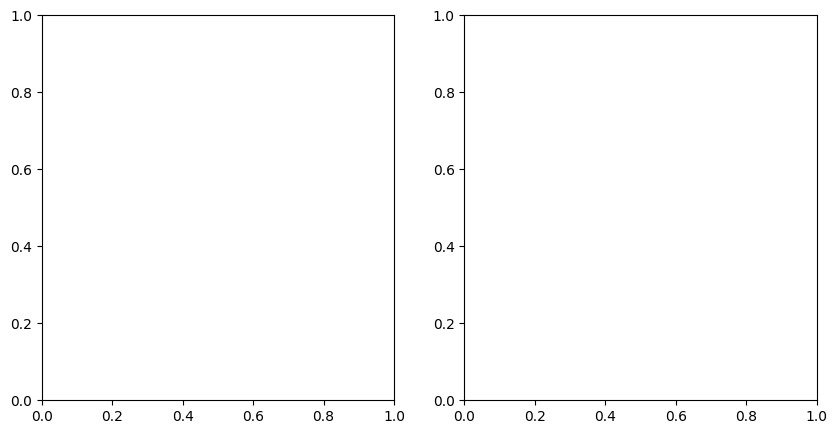

In [14]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "sf_type")
    grid = create_contour_plots(analysis_sample, env, "sf_type")
    create_difference_map(grid, env, "sf_type")

# Compare median $D4000_n$ evolution

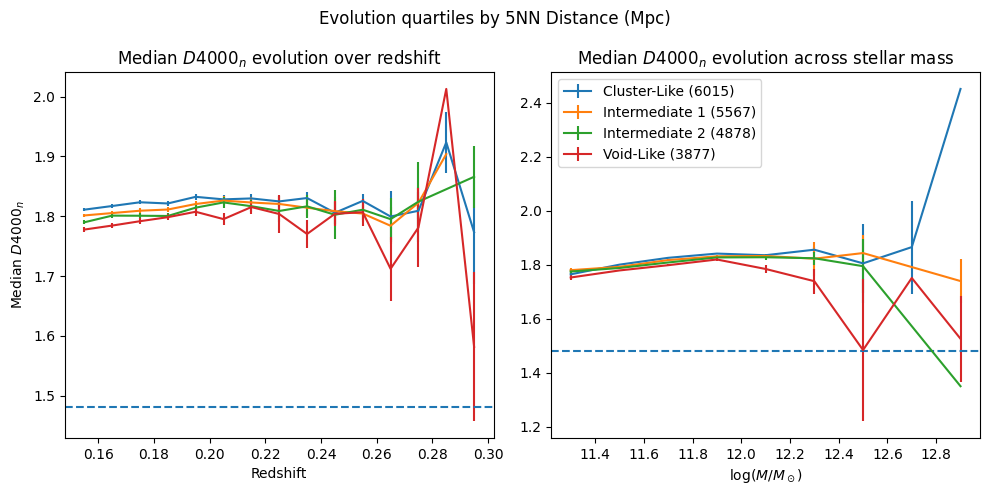

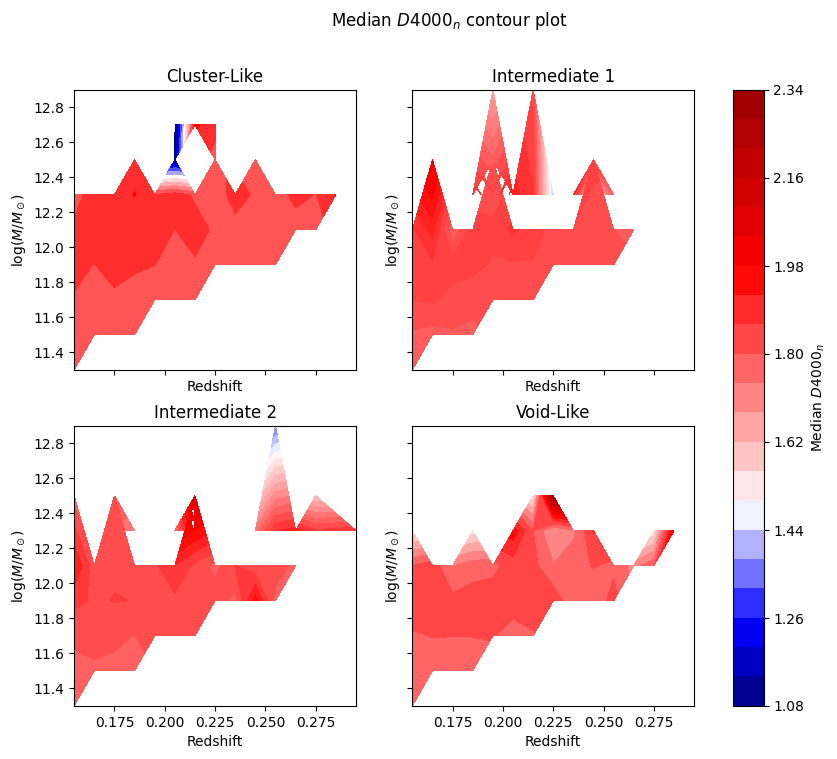

Delta D4000n mean: 0.042 \pm 0.122
Delta D4000n min: -0.525
Delta D4000n max: 0.389


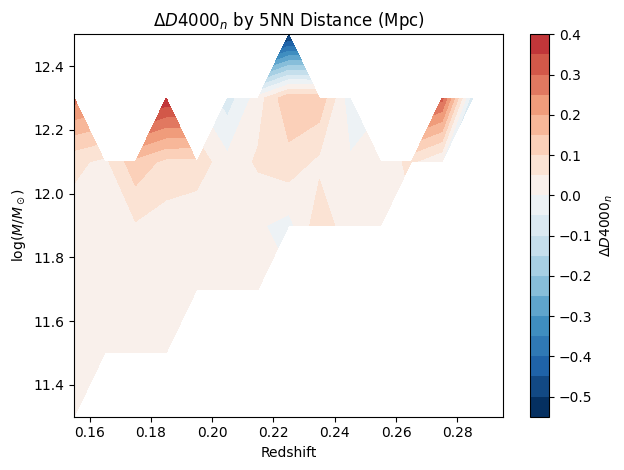

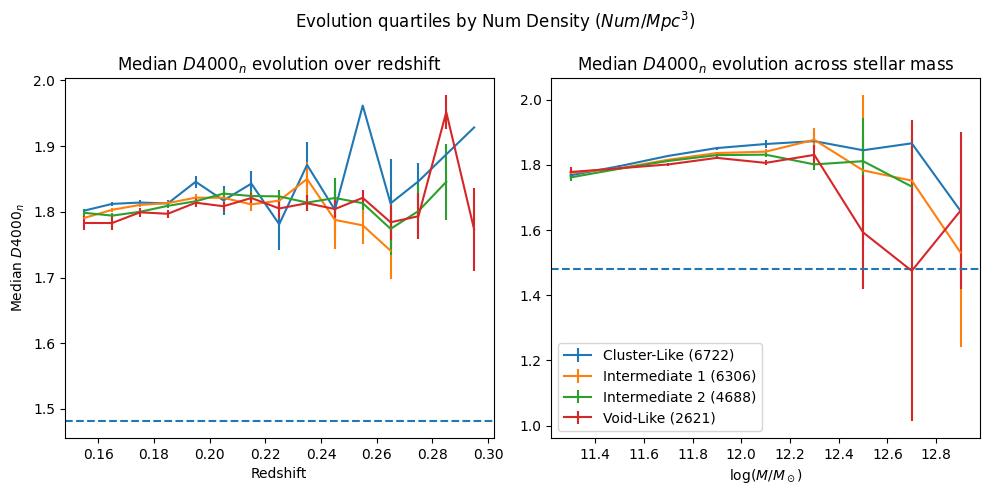

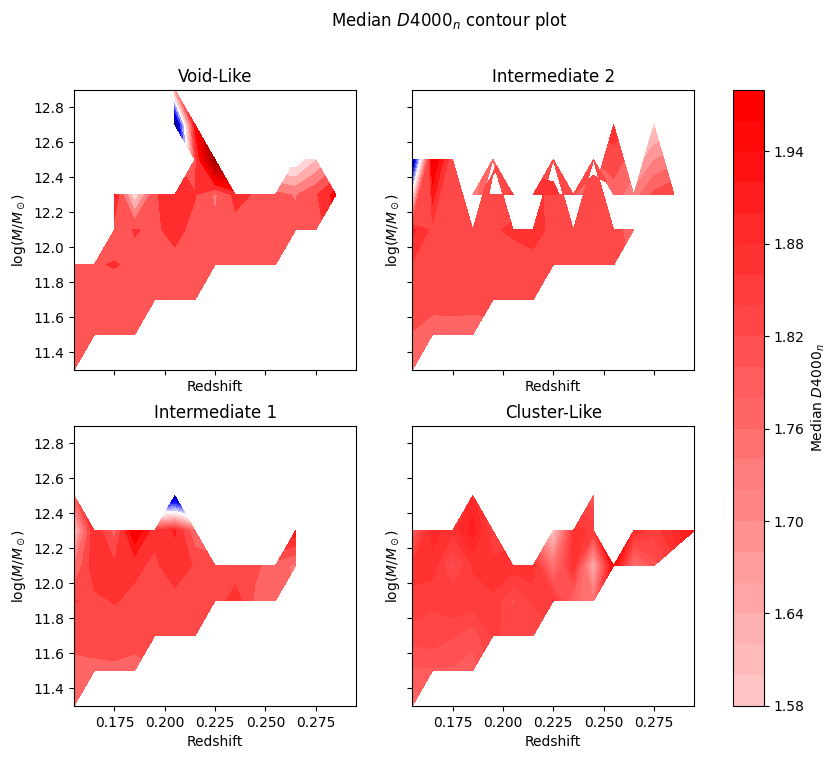

Delta D4000n mean: 0.023 \pm 0.081
Delta D4000n min: -0.177
Delta D4000n max: 0.376


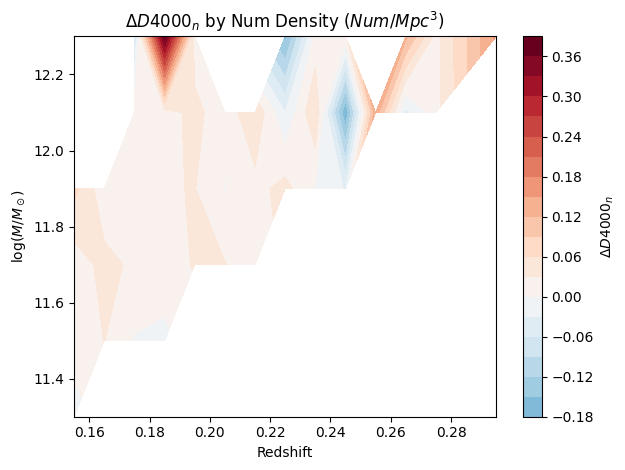

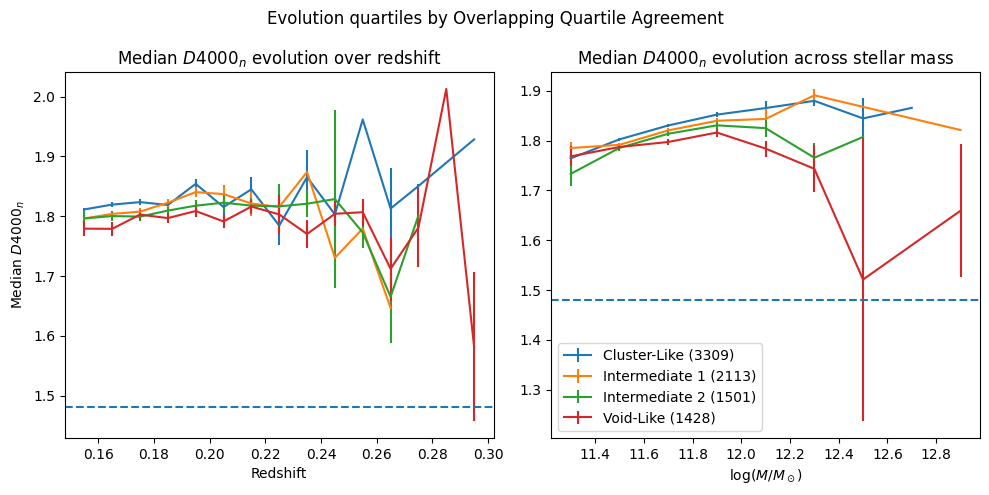

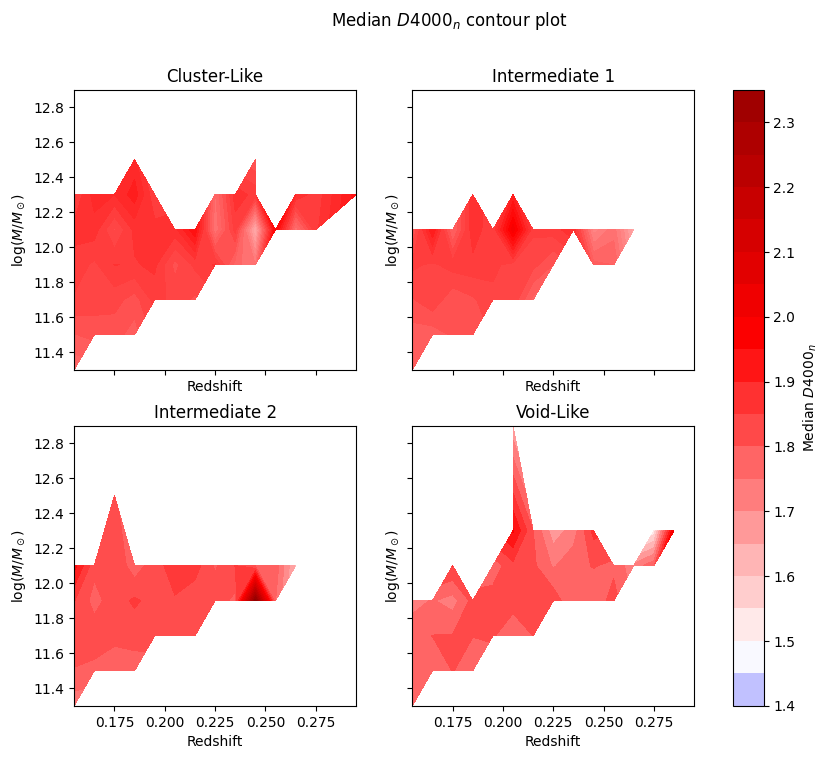

Delta D4000n mean: 0.064 \pm 0.104
Delta D4000n min: -0.170
Delta D4000n max: 0.376


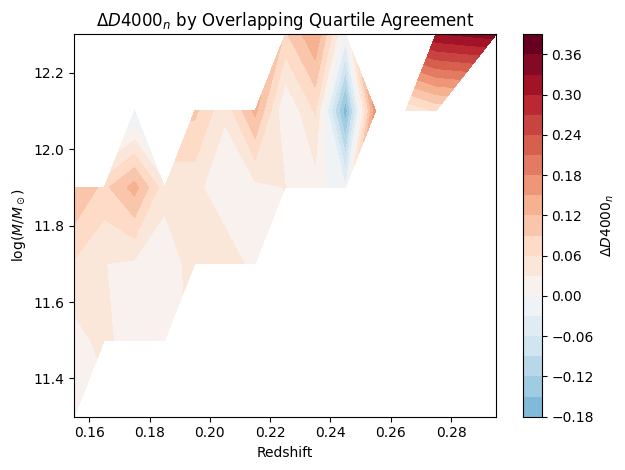

In [ ]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "D4000n")
    grid = create_contour_plots(analysis_sample, env, "D4000n")
    create_difference_map(grid, env, "D4000n")

# Compare median $W_0[H\delta]$ strength evolution

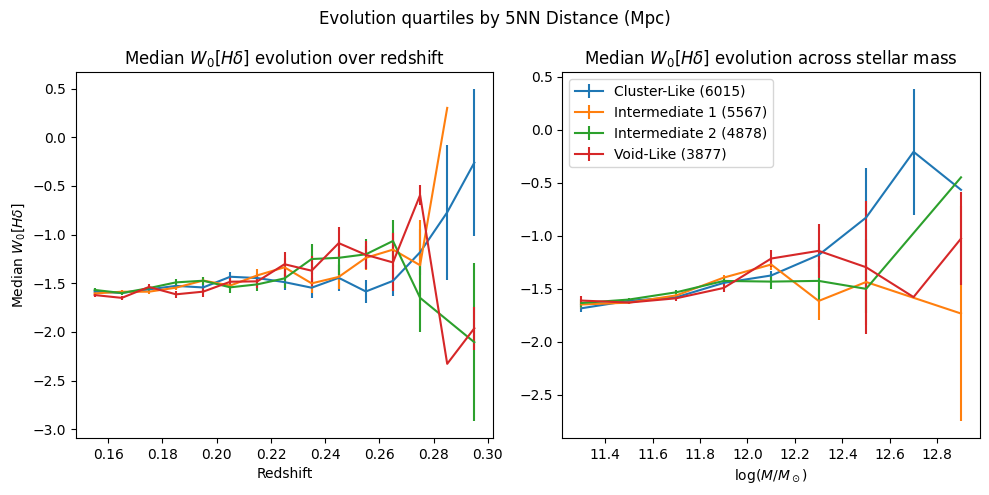

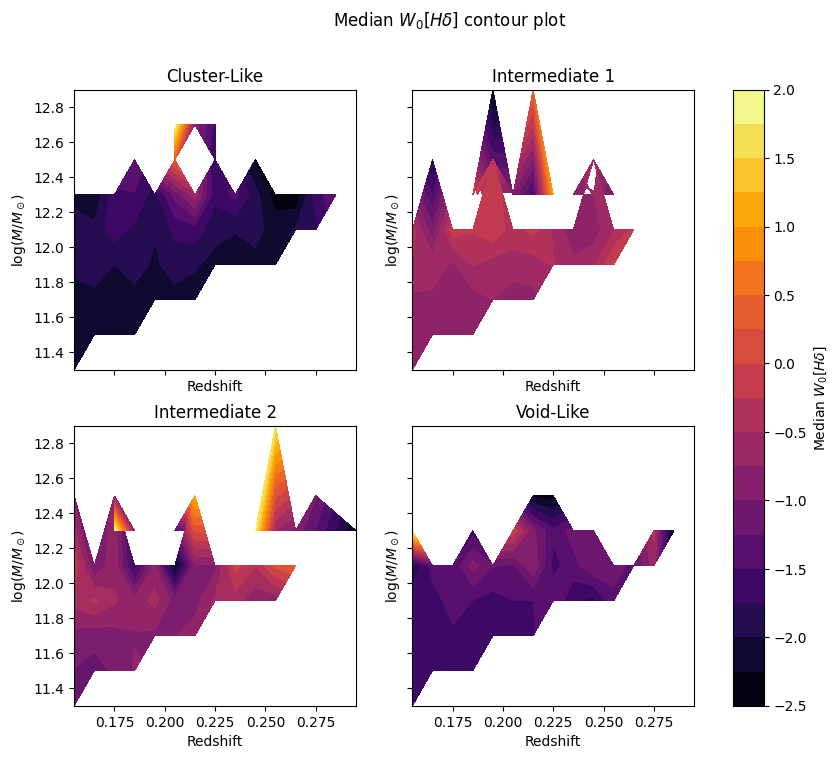

Delta Hd mean: -0.005 \pm 0.713
Delta Hd min: -3.533
Delta Hd max: 1.701


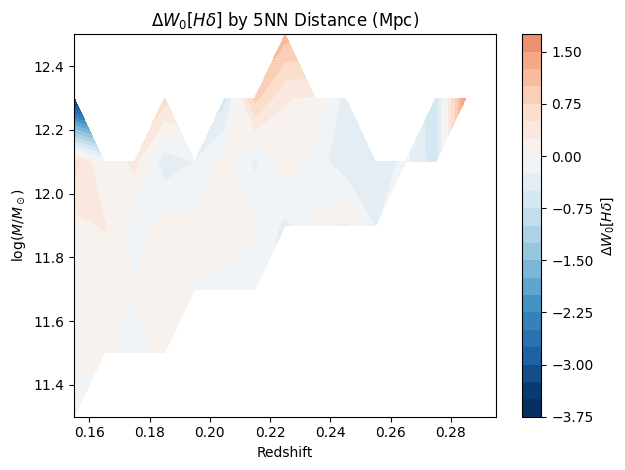

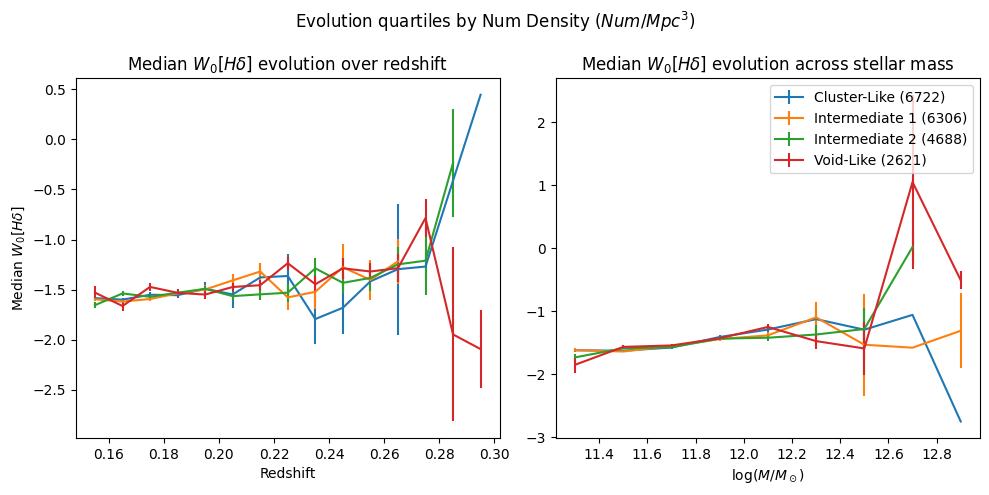

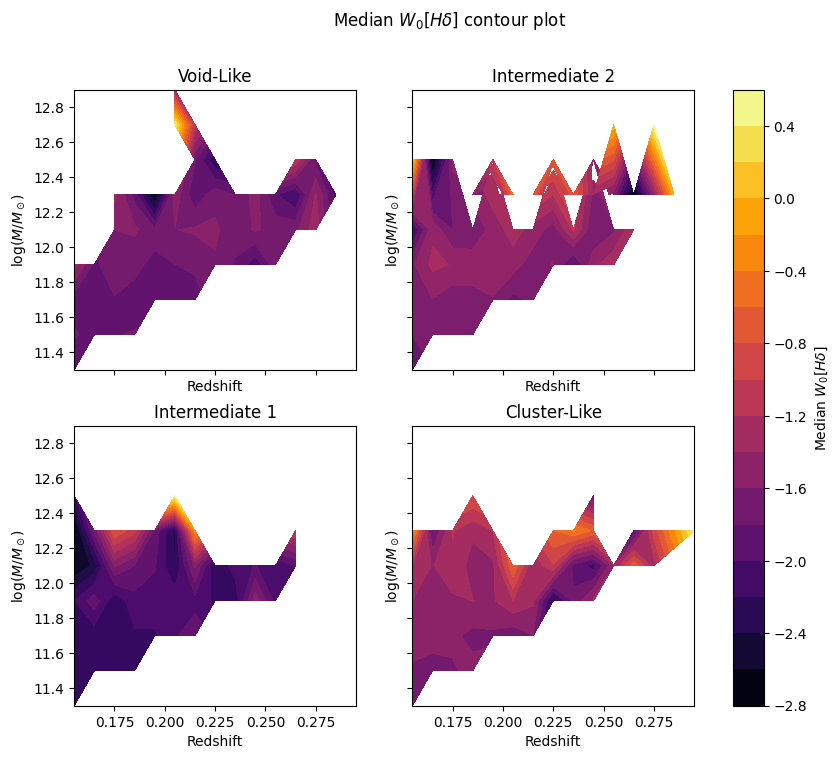

Delta Hd mean: 0.103 \pm 0.635
Delta Hd min: -1.067
Delta Hd max: 2.539


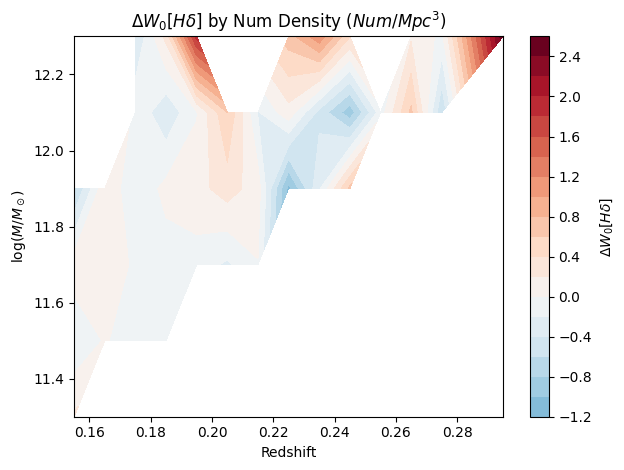

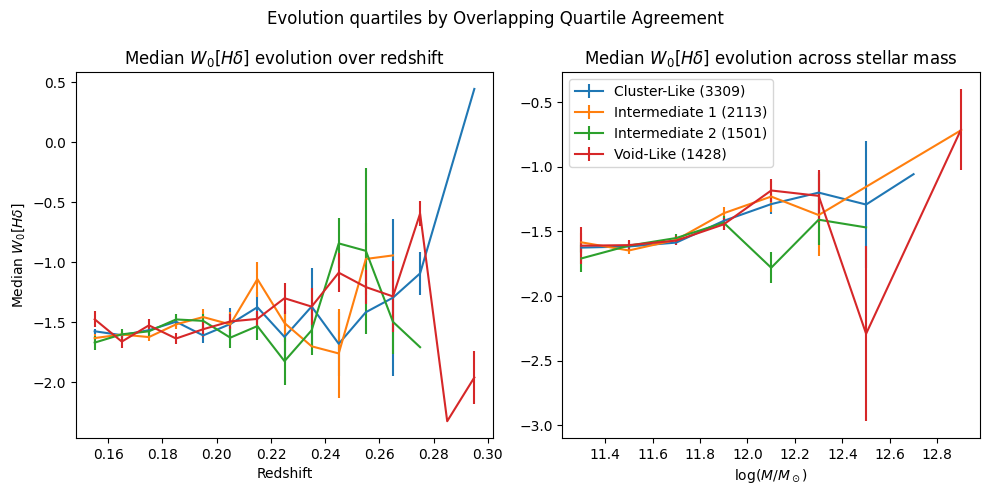

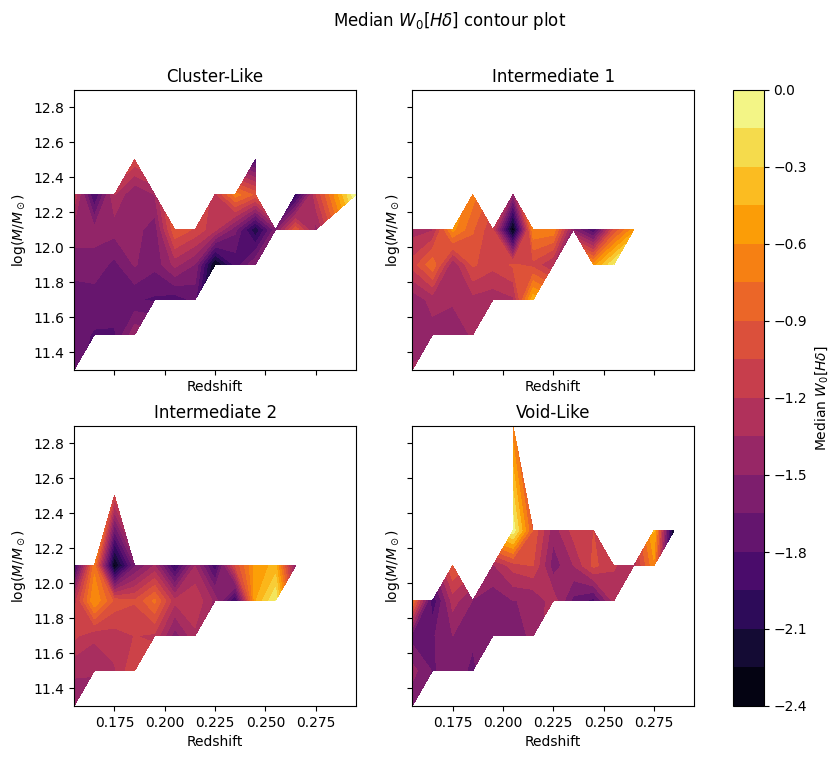

Delta Hd mean: 0.078 \pm 0.580
Delta Hd min: -1.078
Delta Hd max: 2.407


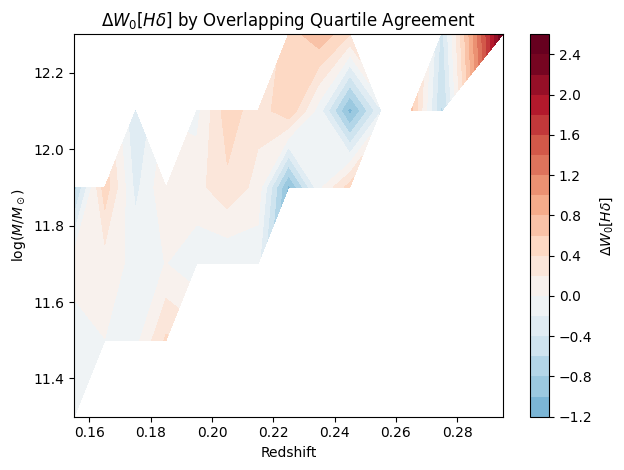

In [ ]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "hd")
    grid = create_contour_plots(analysis_sample, env, "hd")
    create_difference_map(grid, env, "hd")

# Compare median $W_0[OII]$ evolution

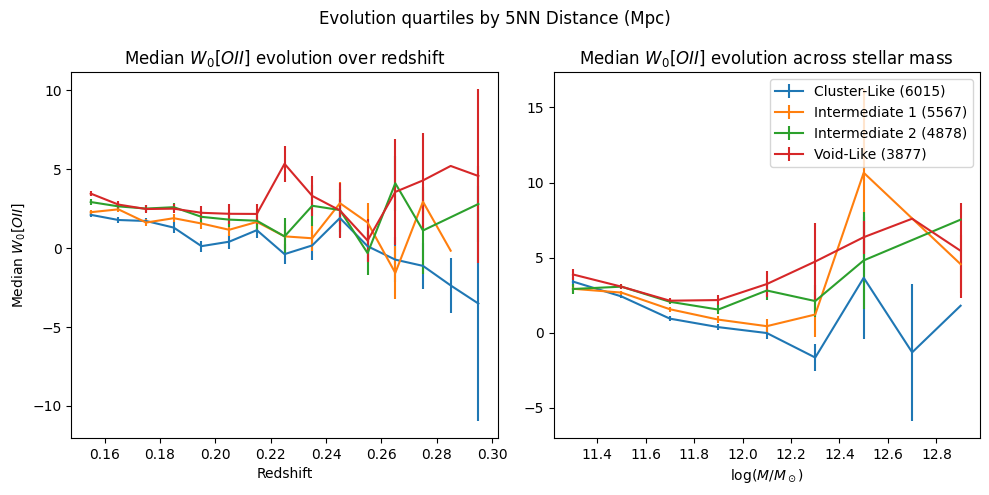

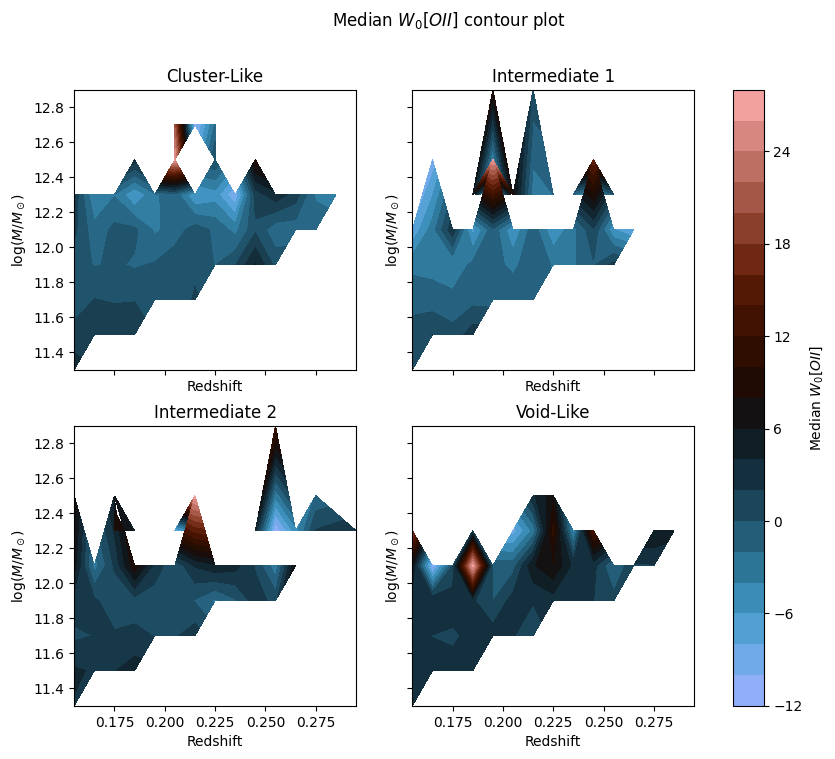

Delta OII mean: -3.074 \pm 5.761
Delta OII min: -26.587
Delta OII max: 10.109


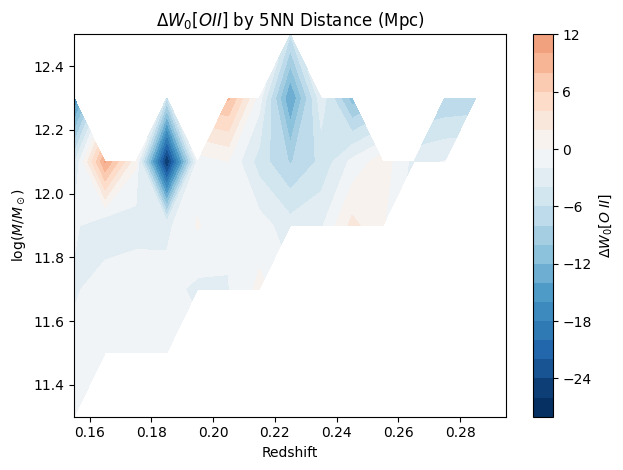

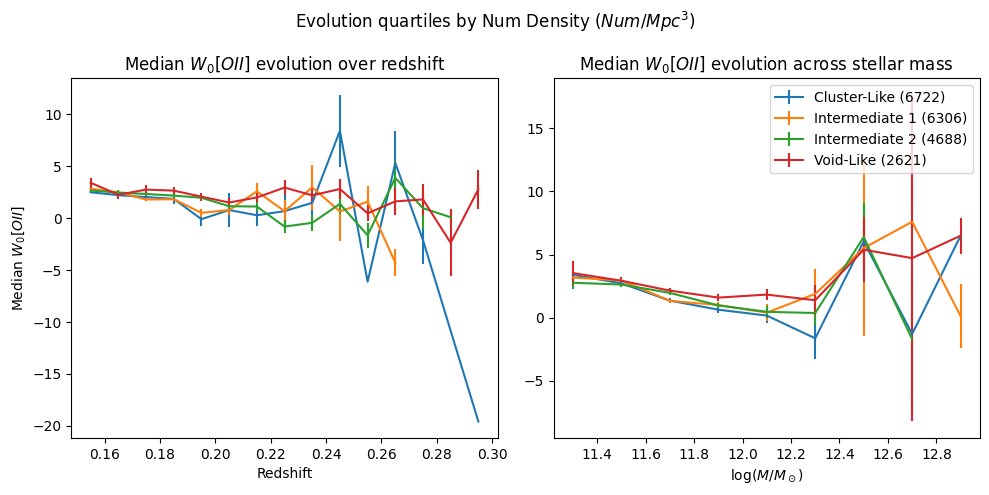

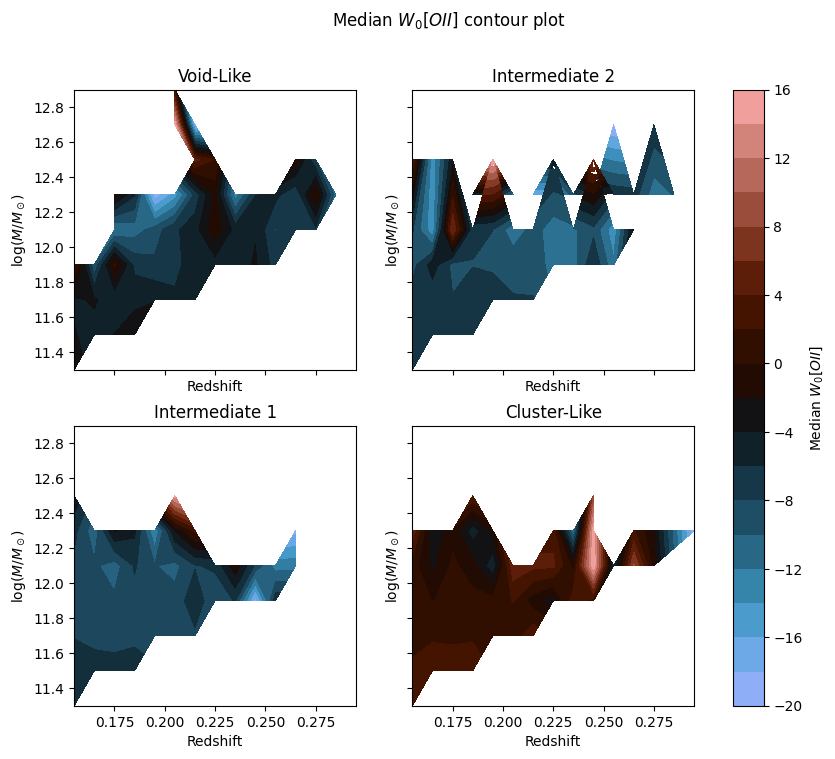

Delta OII mean: -1.036 \pm 5.823
Delta OII min: -22.373
Delta OII max: 13.973


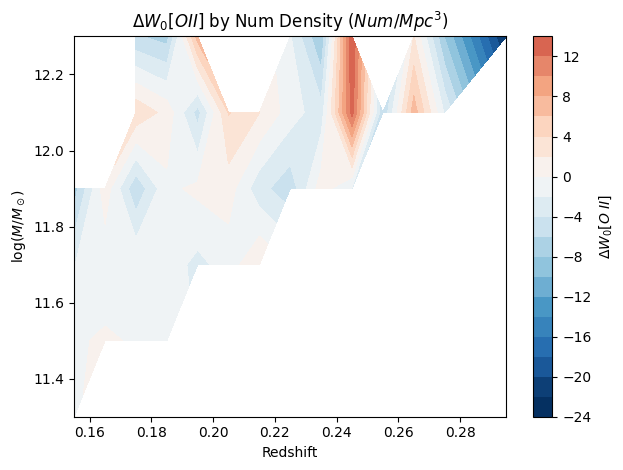

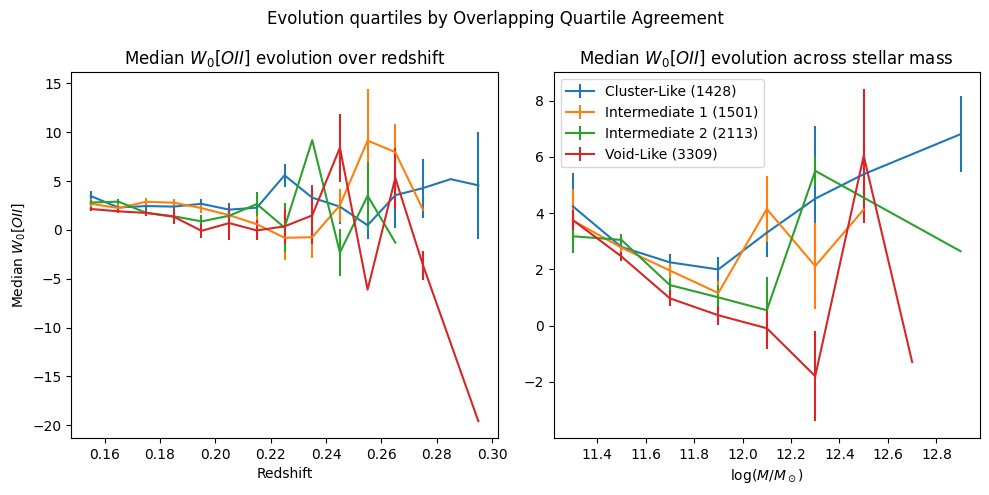

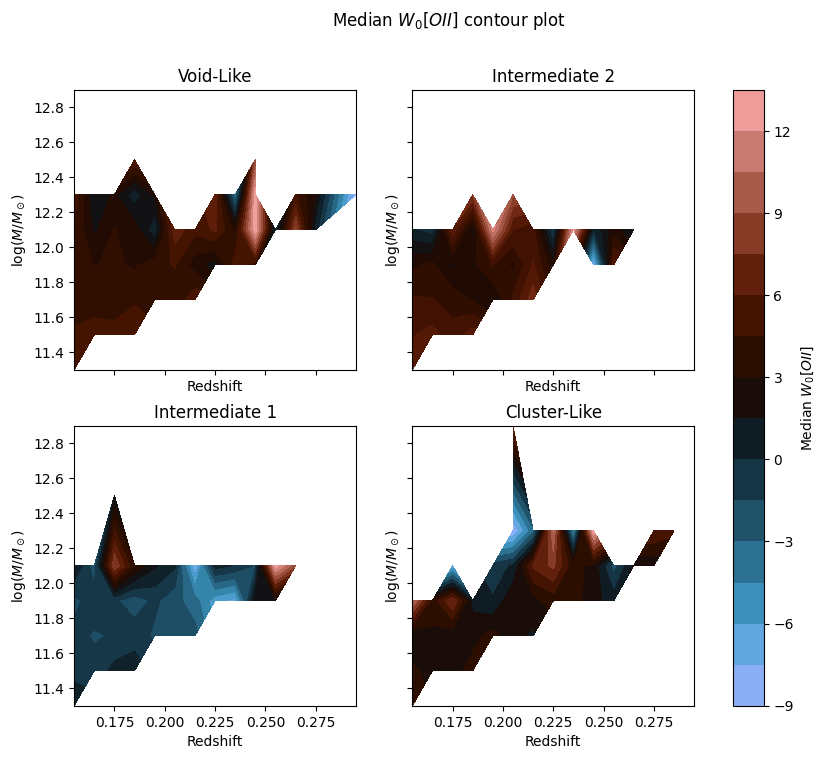

Delta OII mean: 2.228 \pm 5.819
Delta OII min: -13.008
Delta OII max: 24.145


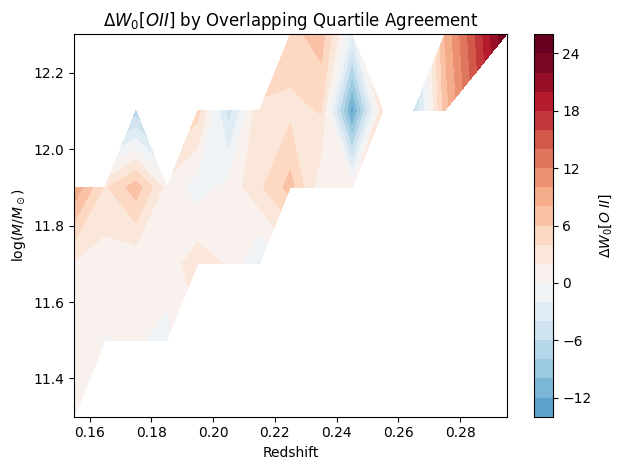

In [ ]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "oii")
    grid = create_contour_plots(analysis_sample, env, "oii")
    create_difference_map(grid, env, "oii")

# Investigate how environment effects distributions of galaxies by class and shape

In [ ]:
def plot_quartile_population_counts(analysis_sample, env_type, population_type):
    """
    Parameters
    ----------
    env_type -> "5NN", "density", "overlap"
    population_type -> "class", "shape"
    """

    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    if population_type == "class":
        col = "class"
        ylabel = "Galaxy Count"
        title_word = "Galaxy Class Distribution"
        image_name = f"../Images/populations/class_counts_{image_split}.png"

    elif population_type == "shape":
        col = "shape"
        ylabel = "Galaxy Count"
        title_word = "Galaxy Morphology Distribution"
        image_name = f"../Images/populations/shape_counts_{image_split}.png"

    # remove unknown rows
    df = analysis_sample[analysis_sample[env_type] != "Unknown"]

    quartiles = df[env_type].unique()

    fig, axes = plt.subplots(2, 2, figsize=(10,8))
    axes = axes.flatten()

    for i, env in enumerate(sorted(quartiles)):

        sub = df[df[env_type] == env]

        counts = sub[col].value_counts().sort_index()

        axes[i].bar(counts.index, counts.values)

        axes[i].set_title(f"{env} ({len(sub)})")
        axes[i].set_ylabel(ylabel)
        axes[i].set_xlabel(col.capitalize())

        axes[i].tick_params(axis='x', rotation=45)

    fig.suptitle(f"{title_word} by {env_word}")

    plt.tight_layout()

    os.makedirs("../Images/populations/", exist_ok=True)
    plt.savefig(image_name)

    plt.show()

In [ ]:
def plot_population_vs_environment(analysis_sample, env_type, population_type):
    """
    Parameters
    ----------
    env_type -> "5NN", "density", "overlap"
    population_type -> "class", "shape"
    """

    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    if population_type == "class":
        col = "class"
        title = "Galaxy Class Counts vs Environment"
        image_name = f"../Images/populations/class_vs_env_{image_split}.png"

    elif population_type == "shape":
        col = "shape"
        title = "Galaxy Morphology Counts vs Environment"
        image_name = f"../Images/populations/shape_vs_env_{image_split}.png"

    df = analysis_sample.copy()
    df = df[df[env_type] != "Unknown"]

    if population_type == "shape":
        # Skip unknown types
        df = df[df["shape"] != "dontknow"]

        # Merge spiral galaxies
        df["shape"] = df["shape"].replace({
            "spiralclock": "spiral",
            "spiralanticlock": "spiral",
            "edgeon": "spiral"
        })

    quartile_order = [
        "Cluster-Like",
        "Intermediate 1",
        "Intermediate 2",
        "Void-Like"
    ]

    df[env_type] = pd.Categorical(df[env_type], categories=quartile_order, ordered=True)

    counts = (
        df.groupby([env_type, col], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(quartile_order)
    )

    x = np.arange(len(quartile_order))

    plt.figure(figsize=(7,5))

    for population in counts.columns:
        plt.plot(
            x,
            counts[population],
            marker='o',
            label=population
        )

    plt.xticks(x, quartile_order, rotation=30)
    plt.ylabel("Galaxy Count")
    plt.xlabel("Environment Quartile")

    plt.title(title)
    plt.suptitle(f"Environment measured by {env_word}")

    plt.legend()
    plt.yscale("log")
    plt.tight_layout()

    os.makedirs("../Images/populations/", exist_ok=True)
    plt.savefig(image_name)

    plt.show()

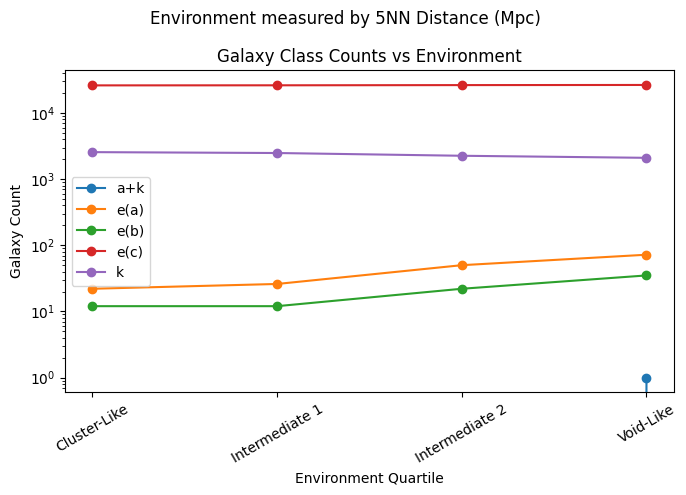

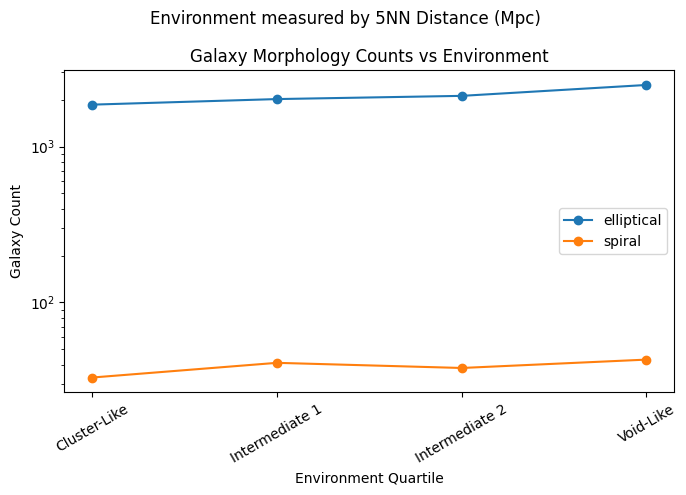

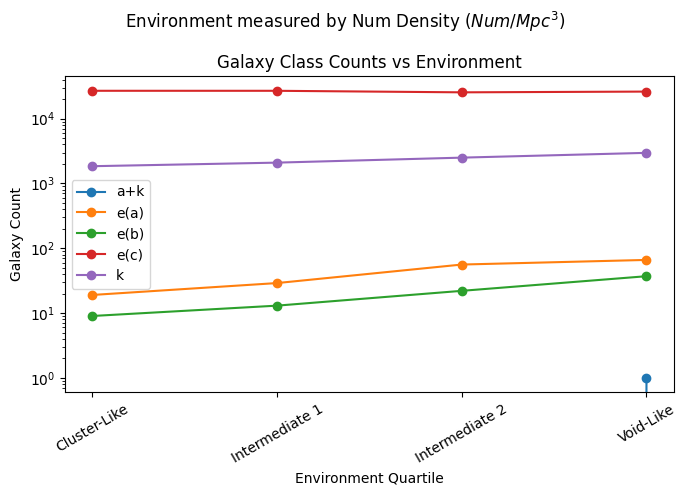

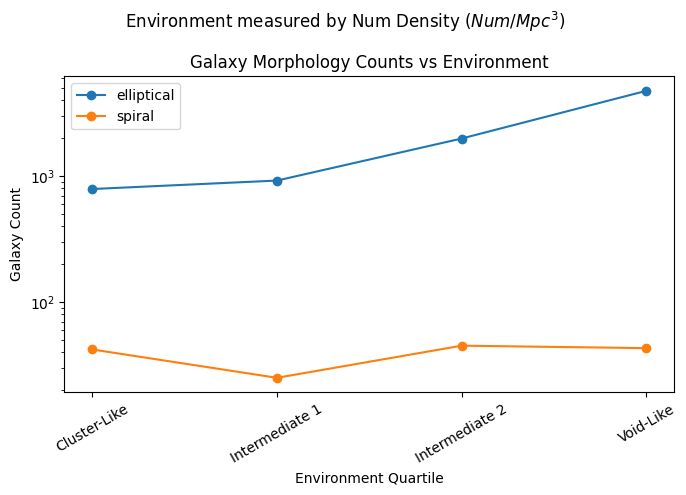

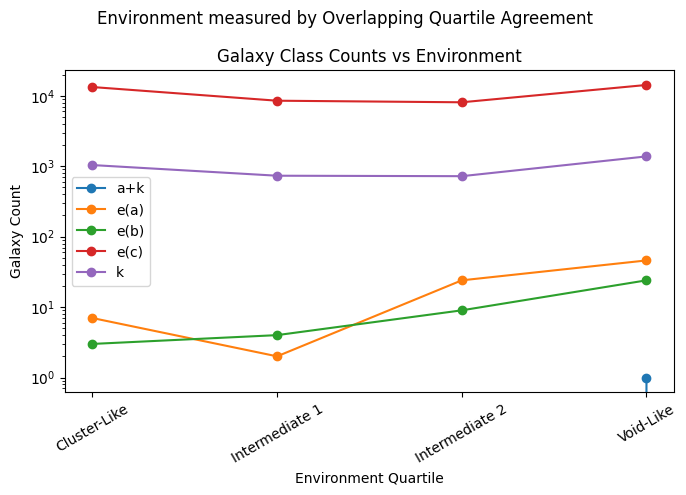

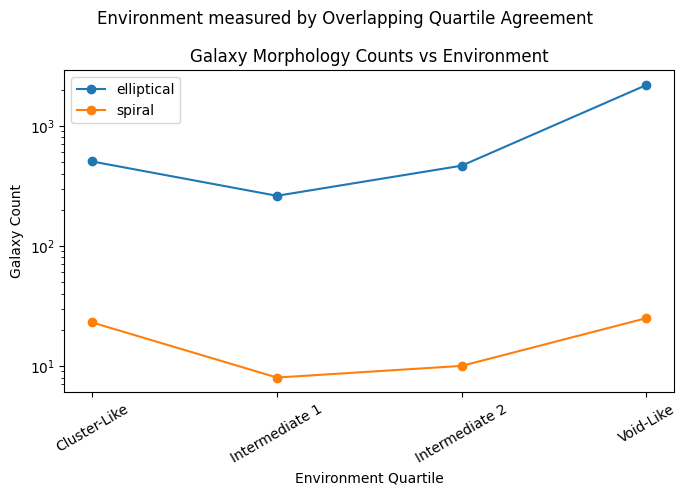

In [ ]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_population_vs_environment(mass_df, env, "class")
    plot_population_vs_environment(mass_df, env, "shape")